In [ ]:
import os 
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import numpy as np
from torchvision import transforms,datasets
import torch.optim as optim
from torch.autograd import Variable
from torch.optim.lr_scheduler import ReduceLROnPlateau
# #from focal_loss.focal_loss import FocalLoss
# import torchvision
# import sys
from torchsummary import summary
# from ptflops import get_model_complexity_info
# from torchinfo import summary
# from torchstat import stat
import h5py
from torch.utils.data import DataLoader, random_split,ConcatDataset
from torch.optim.lr_scheduler import StepLR
# import pytorch_lightning as pl
import fastmri
from fastmri.data import transforms
from fastmri.data.subsample import RandomMaskFunc, EquiSpacedMaskFunc
from fastmri.data import SliceDataset
from fastmri.data.mri_data import fetch_dir
# from fastmri.data.transforms import UnetDataTransform
# from fastmri.pl_modules import FastMriDataModule, UnetModule
# from argparse import ArgumentParser
from fastmri.losses import SSIMLoss 
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

import matplotlib.pyplot as plt
import time
from torchvision import models
# import os
import torch
import torch.nn as nn
import torch.nn.functional as F

from loss_function.utils_gradlossUpdated import DualStreamLoss
from tqdm import tqdm
import logging

<font size='7'>**ELiTNet Model**<font>

In [2]:
def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

class ConvBlock(torch.nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, shortcut=False, pool=True):
        '''
        pool_mode can be False (no pooling) or True ('maxpool')
        '''
        super(ConvBlock, self).__init__()
        if shortcut==True: self.shortcut = nn.Sequential(conv1x1(in_c, out_c), nn.BatchNorm2d(out_c))
        else: self.shortcut=False
        pad = (k_sz - 1) // 2

        block = []
        if pool: self.pool = nn.MaxPool2d(kernel_size=2)
        else: self.pool = False

        block.append(nn.Conv2d(in_c, out_c, kernel_size=k_sz, padding=pad))
        block.append(nn.ReLU())
        block.append(nn.BatchNorm2d(out_c))

        block.append(nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding=pad))
        block.append(nn.ReLU())
        block.append(nn.BatchNorm2d(out_c))

        self.block = nn.Sequential(*block)
    def forward(self, x):
        if self.pool: x = self.pool(x)
        out = self.block(x)
        if self.shortcut: return out + self.shortcut(x)
        else: return out
        
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, dilation = [1,2,3]):
        super(ResBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_c)
        #self.relu = nn.ReLU(inplace=True)
        self.mish = nn.GELU()
        self.conv1 = nn.Conv2d(in_c, out_c // 4 , 1)
        self.bn2 = nn.BatchNorm2d(out_c // 4)
        #self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_c // 4, out_c // 4, 3, padding='same')
        # self.conv3 = nn.Conv2d(out_c * 4, out_c, 3, padding='same', dilation=dilation[1])
        # self.conv4 = nn.Conv2d(out_c * 4, out_c, 3, padding='same', dilation=dilation[2])
        
        
        #self.conv2 = nn.Conv2d(output_channels/4, output_channels/4, 3, stride, padding = 1, bias = False)
        self.dropout = nn.Dropout(0.2)
        self.bn3 = nn.BatchNorm2d(out_c // 4)
        #self.relu = nn.ReLU(inplace=True)
        self.conv5 = nn.Conv2d(out_c // 4, out_c, 1, 1, bias = False)
        self.conv6 = nn.Conv2d(in_c, out_c , 1, 1, padding='same', bias = False)
        
    def forward(self, x):
        #residual = x
        #out = self.bn1(x)
        #out = self.mish(out)
        out = self.conv1(x)
        #out = self.bn2(out)
        out = self.mish(out)
        out = self.conv2(out)
        # out2 = self.conv3(out)
        # out3 = self.conv4(out)
        # out = torch.add(torch.add(out1,out2),out3)
        #out =  self.conv2(out)+ self.conv3(out)+ self.conv4(out)
        out = self.bn3(out)
        out = self.dropout(out)
        out = self.mish(out)
        out = self.conv5(out)
        
       
        #if (self.input_channels != self.output_channels) or (self.stride !=1 ):
        residual = self.conv6(x)
        out += residual
        return out


class AttConvBlock(torch.nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, shortcut=False, pool=True, attention=False):
        '''
        pool_mode can be False (no pooling) or True ('maxpool')
        '''
        super(AttConvBlock, self).__init__()
        if shortcut==True: self.shortcut = nn.Sequential(conv1x1(in_c, out_c), nn.BatchNorm2d(out_c))
        else: self.shortcut=False
        pad = (k_sz - 1) // 2

        if pool: self.pool = nn.MaxPool2d(kernel_size=2)
        else: self.pool = False

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=k_sz, padding=pad),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding=pad),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )
        if attention==True:
            self.mpool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

            #self.softmax1_blocks = DiResBlock(in_c, out_c, dilation= [1,2,4])
            self.softmax1_blocks = nn.Conv2d(in_c, out_c, kernel_size=k_sz, padding='same', dilation= 2)

            self.skip1_connection_residual_block = nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding='same')

            self.mpool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

            #self.softmax2_blocks = DiResBlock(out_c, out_c, dilation= [2,4,8])
            self.softmax2_blocks = nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding='same', dilation= 4)

            self.skip2_connection_residual_block = nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding='same')

            self.mpool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

            self.softmax3_blocks = nn.Sequential(
                nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding='same', dilation= 8),
                nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding='same', dilation= 8)
            )

            self.interpolation3 = nn.UpsamplingBilinear2d(scale_factor=2)

            #self.softmax4_blocks = DiResBlock(out_c, out_c, dilation= [2,4,8])
            self.softmax4_blocks = nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding='same', dilation= 4)

            self.interpolation2 = nn.UpsamplingBilinear2d(scale_factor=2)

            #self.softmax5_blocks = DiResBlock(out_c, out_c, dilation= [1,2,4])
            self.softmax5_blocks = nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding='same', dilation= 2)

            self.interpolation1 = nn.UpsamplingBilinear2d(scale_factor=2)

            self.softmax6_blocks = nn.Sequential(
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c , kernel_size = 1, stride = 1, bias = False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c , kernel_size = 1, stride = 1, bias = False),
                nn.Sigmoid()
            )

            self.last_blocks = nn.Conv2d(out_c, out_c, kernel_size=k_sz, padding='same')
        
    def forward(self, x, attention = False):
        if self.pool: x = self.pool(x)
        out_trunk = self.conv(x)
        if attention==True:
            out_mpool1 = self.mpool1(x)
            out_softmax1 = self.softmax1_blocks(out_mpool1)
            out_skip1_connection = self.skip1_connection_residual_block(out_softmax1)
            out_mpool2 = self.mpool2(out_softmax1)
            out_softmax2 = self.softmax2_blocks(out_mpool2)
            #print(out_softmax2.data.shape)
            out_skip2_connection = self.skip2_connection_residual_block(out_softmax2)
            out_mpool3 = self.mpool3(out_softmax2)
            out_softmax3 = self.softmax3_blocks(out_mpool3)
            #
            out_interp3 = self.interpolation3(out_softmax3)
            #print(out_skip2_connection.data.shape)
            #print(out_interp3.data.shape)
            out = torch.add(out_interp3, out_skip2_connection)
            out_softmax4 = self.softmax4_blocks(out)
            out_interp2 = self.interpolation2(out_softmax4)
            out = torch.add(out_interp2, out_skip1_connection)
            out_softmax5 = self.softmax5_blocks(out)
            out_interp1 = self.interpolation1(out_softmax5)
            out_softmax6 = self.softmax6_blocks(out_interp1)
            #print(out_softmax6.shape)
            #print(out_trunk.shape)
            out = torch.multiply((1 + out_softmax6), out_trunk)
            out = self.last_blocks(out)
        else:
            out = out_trunk
        if self.shortcut: return out + self.shortcut(x)
        else: return out
        
        
class UpsampleBlock(torch.nn.Module):
    def __init__(self, in_c, out_c, up_mode='transp_conv'):
        super(UpsampleBlock, self).__init__()
        block = []
        if up_mode == 'transp_conv':
            block.append(nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2))
        elif up_mode == 'up_conv':
            block.append(nn.UpsamplingBilinear2d(scale_factor=2))
            block.append(nn.Conv2d(in_c, out_c, kernel_size=1))
        else:
            raise Exception('Upsampling mode not supported')

        self.block = nn.Sequential(*block)

    def forward(self, x):
        out = self.block(x)
        return out
    
class DoubleAttBlock(torch.nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, shortcut= True, attention = True):
        super(DoubleAttBlock, self).__init__()
        

        self.block1 = AttConvBlock(in_c, in_c, k_sz=k_sz,
                              shortcut=shortcut, pool=False, attention=attention)
        self.block2 = AttConvBlock(in_c, out_c, k_sz=k_sz,
                              shortcut=shortcut, pool=True, attention=attention)

    def forward(self, x):
        out = self.block1(x, attention = True)
        out = self.block2(out, attention = True)
        return out

class ConvBridgeBlock(torch.nn.Module):
    def __init__(self, channels, k_sz=3):
        super(ConvBridgeBlock, self).__init__()
        # pad = (k_sz - 1) // 2
        # block=[]

        # block.append(nn.Conv2d(channels, channels, kernel_size=k_sz, padding=pad))
        # block.append(nn.ReLU())
        # block.append(nn.BatchNorm2d(channels))

        # self.block = nn.Sequential(*block)
        self.block = ResBlock(channels, channels)

    def forward(self, x):
        out = self.block(x)
        return out

class UpConvBlock(torch.nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, up_mode='up_conv', conv_bridge=False, shortcut=False):
        super(UpConvBlock, self).__init__()
        self.conv_bridge = conv_bridge

        self.up_layer = UpsampleBlock(in_c, out_c, up_mode=up_mode)
        self.conv_layer1 = AttConvBlock(out_c, out_c, k_sz=k_sz, shortcut=shortcut, pool=False, attention= True)
        self.conv_layer2 = AttConvBlock(2 * out_c, out_c, k_sz=k_sz, shortcut=shortcut, pool=False, attention= True)
        if self.conv_bridge:
            self.conv_bridge_layer = ConvBridgeBlock(out_c, k_sz=k_sz)

    def forward(self, x, skip):
        up = self.up_layer(x)
        up = self.conv_layer1(up, attention = True)
        #skip = torch.multiply((1 + up), skip)
        if self.conv_bridge:
            skip = self.conv_bridge_layer(skip)
            skip = torch.multiply((1 + up), skip)
            out = torch.cat([up, skip], dim=1) 
        else:
            skip = torch.multiply((1 + up), skip)
            out = torch.cat([up, skip], dim=1)
        out = self.conv_layer2(out, attention = True)
        return out

class ELiTNet(nn.Module):
    def __init__(self, in_c, n_classes, layers, k_sz=3, up_mode='up_conv', conv_bridge=True, shortcut=True):
        super(ELiTNet, self).__init__()
        self.n_classes = n_classes
        self.first = ConvBlock(in_c=in_c, out_c=layers[0], k_sz=k_sz,
                               shortcut=shortcut, pool=False)

        self.down_path = nn.ModuleList()
        for i in range(len(layers) - 1):
            block = DoubleAttBlock(in_c=layers[i], out_c=layers[i + 1], k_sz=k_sz,
                              shortcut=shortcut, attention=True)
            self.down_path.append(block)

        self.up_path = nn.ModuleList()
        reversed_layers = list(reversed(layers))
        for i in range(len(layers) - 1):
            block = UpConvBlock(in_c=reversed_layers[i], out_c=reversed_layers[i + 1], k_sz=k_sz,
                                up_mode=up_mode, conv_bridge=conv_bridge, shortcut=shortcut)
            self.up_path.append(block)

        # init, shamelessly lifted from torchvision/models/resnet.py
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        self.final = nn.Conv2d(layers[0], n_classes, kernel_size=1)

    def forward(self, x):
        x = self.first(x)
        down_activations = []
        for i, down in enumerate(self.down_path):
            down_activations.append(x)
            x = down(x)
        down_activations.reverse()
        for i, up in enumerate(self.up_path):
            x = up(x, down_activations[i])
        return self.final(x)  

In [3]:
if __name__ == "__main__":
    image = torch.rand((1,1,320,320))
    model = ELiTNet(in_c=1, n_classes=1, layers=[32,64,128,256], conv_bridge=True, shortcut=True)
    print(model(image).shape)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = model.to(device)
summary(model, input_size=(1, 320, 320), batch_size=1, device=str(device)) 

torch.Size([1, 1, 320, 320])
cuda
Layer (type:depth-idx)                             Param #
├─ConvBlock: 1-1                                   --
|    └─Sequential: 2-1                             --
|    |    └─Conv2d: 3-1                            32
|    |    └─BatchNorm2d: 3-2                       64
|    └─Sequential: 2-2                             --
|    |    └─Conv2d: 3-3                            320
|    |    └─ReLU: 3-4                              --
|    |    └─BatchNorm2d: 3-5                       64
|    |    └─Conv2d: 3-6                            9,248
|    |    └─ReLU: 3-7                              --
|    |    └─BatchNorm2d: 3-8                       64
├─ModuleList: 1-2                                  --
|    └─DoubleAttBlock: 2-3                         --
|    |    └─AttConvBlock: 3-9                      105,120
|    |    └─AttConvBlock: 3-10                     380,224
|    └─DoubleAttBlock: 2-4                         --
|    |    └─AttConvBlock: 3-1

Layer (type:depth-idx)                             Param #
├─ConvBlock: 1-1                                   --
|    └─Sequential: 2-1                             --
|    |    └─Conv2d: 3-1                            32
|    |    └─BatchNorm2d: 3-2                       64
|    └─Sequential: 2-2                             --
|    |    └─Conv2d: 3-3                            320
|    |    └─ReLU: 3-4                              --
|    |    └─BatchNorm2d: 3-5                       64
|    |    └─Conv2d: 3-6                            9,248
|    |    └─ReLU: 3-7                              --
|    |    └─BatchNorm2d: 3-8                       64
├─ModuleList: 1-2                                  --
|    └─DoubleAttBlock: 2-3                         --
|    |    └─AttConvBlock: 3-9                      105,120
|    |    └─AttConvBlock: 3-10                     380,224
|    └─DoubleAttBlock: 2-4                         --
|    |    └─AttConvBlock: 3-11                     419,136
|   

<font size='5'>**Dataloader**<font>

In [4]:
class CustomKneeDataset(SliceDataset):
    def __init__(self, root, transform, challenge='multicoil', sample_rate=1.0):
        super().__init__(root=root, challenge=challenge, transform=transform, sample_rate=sample_rate)
        self.data_path = root
        self.files = sorted(os.listdir(self.data_path))
        self.h5_files = [h5py.File(os.path.join(self.data_path, fname), 'r') for fname in self.files]
    
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        subject_data_path = os.path.join(self.data_path, fname)
        
        # Use SWMR (single-writer multiple-reader) mode to avoid issues with concurrent access
        with h5py.File(subject_data_path, 'r') as data:
            kspace = data['kspace'][:]
            target = data['reconstruction_rss'][:]
            attrs = dict(data.attrs)

        slice_idx = np.random.randint(5, kspace.shape[0])  # Randomly select a slice, excluding the first 5 slices
        return self.transform(kspace[slice_idx], target[slice_idx], attrs, fname, slice_idx)
    

class DataTransform:
    def __init__(self, mask_func, resolution, which_challenge, use_seed=True):
        if which_challenge not in ('singlecoil', 'multicoil'):
            raise ValueError('Challenge should either be "singlecoil" or "multicoil"')
        self.mask_func = mask_func
        self.resolution = resolution
        self.which_challenge = which_challenge
        self.use_seed = use_seed

    def __call__(self, kspace, target, attrs, fname, slice_idx):
        kspace = transforms.to_tensor(kspace)
        seed = None if not self.use_seed else tuple(map(ord, fname))
        masked_kspace, mask, _ = transforms.apply_mask(kspace, self.mask_func, seed)
        image = fastmri.ifft2c(masked_kspace)
        image = transforms.complex_center_crop(image, (self.resolution, self.resolution))
        image = fastmri.complex_abs(image)
        if self.which_challenge == 'multicoil':
            image = fastmri.rss(image)
        image, mean, std = transforms.normalize_instance(image, eps=1e-11)
        image = image.clamp(-6, 6)

        target = transforms.to_tensor(target)
        target = transforms.normalize(target, mean, std, eps=1e-11)
        target = target.clamp(-6, 6)

        return image, target, mean, std, attrs['norm'].astype(np.float32)

def create_data_loaders(train_data_paths, mask_func, batch_size, resolution, challenge='multicoil', 
                        sample_rate=1.0):
    transform = DataTransform(mask_func, resolution, challenge)
    
    # # Create a dataset for each directory and concatenate them
    # datasets = [CustomKneeDataset(root=path, transform=transform, challenge=challenge, 
    #                               sample_rate=sample_rate) for path in train_data_paths]
    # full_dataset = ConcatDataset(datasets)  # Combines all datasets from multiple folders
    
    # # Split the concatenated dataset into 80% training and 20% validation
    # train_size = int(0.8 * len(full_dataset))
    # val_size = len(full_dataset) - train_size
    # train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_datasets = [CustomKneeDataset(root=path, transform=transform, challenge=challenge, 
                                  sample_rate=sample_rate) for path in train_data_paths]
    train_dataset = ConcatDataset(train_datasets)  # Combines all datasets from multiple folders


    # Validation DataLoader
    val_dataset = CustomKneeDataset(root=val_data_path, transform=transform, challenge=challenge, 
                                  sample_rate=sample_rate)

    # Training Volumes
    print(f"Training dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,  # Adjust based on your system's resources
        pin_memory=True,
    )

    val_loader = DataLoader(
        dataset=val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=8,  # Adjust based on your system's resources
        pin_memory=True,
    )

    return train_loader, val_loader


# Train and Validation Dataloader. 
train_data_paths = [
    "/home/susant/Knee_Multicoil_train_batch0/multicoil_train",
    "/home/susant/Knee_Multicoil_train_batch1/multicoil_train"
    ]

val_data_path = "/storage/FastMRI/Knee/knee_multicoil_val_subset"
mask_func = RandomMaskFunc(center_fractions=[0.04], accelerations=[8])
resolution = 320
batch_size = 4


num_epochs = 2
learning_rate = 0.001
save_every = 40
save_dir = "/home/susant/ELiTNet_savedModels"
os.makedirs(save_dir, exist_ok=True)

train_loader, val_loader = create_data_loaders(train_data_paths, mask_func, batch_size, 
                                               resolution, challenge='multicoil', sample_rate=1.0)

Training dataset size: 391
Validation dataset size: 80


<font size='5'>**Data Visualization**<font>

In [4]:
def show_slices(data, slice_nums, cmap=None): # visualisation
    fig = plt.figure(figsize=(8,8))
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        plt.imshow(data[num], cmap=cmap)
        plt.axis('off')

ssim : 0.45048517467578714
Train Image Shape: torch.Size([4, 320, 320])


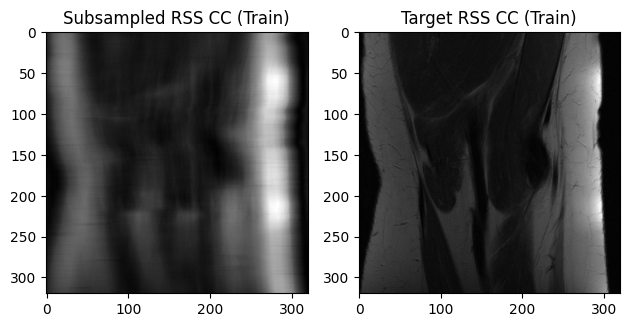

Val Image Shape: torch.Size([4, 320, 320])


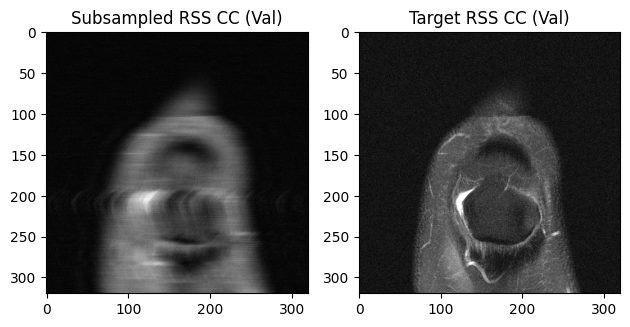

: 

In [ ]:
# Visualization code (for a single batch of training data)
train_data_sample = next(iter(train_loader))
images, targets, mean, std, norms = train_data_sample

images_np = images.squeeze().cpu().numpy()
targets_np = targets.squeeze().cpu().numpy()
batch_ssim = 0.0
for i in range(batch_size):
    batch_ssim = batch_ssim + ssim(images_np[i], targets_np[i], data_range=targets_np.max()-targets_np.min()).item()

batch_ssim = batch_ssim/batch_size
print('ssim :', batch_ssim)

print(f'Train Image Shape: {images.shape}')
plt.subplot(1,2,1)
plt.imshow(images[0].squeeze(0), cmap="gray")
plt.title('Subsampled RSS CC (Train)')
plt.subplot(1,2,2)
plt.imshow(targets[0].squeeze(0), cmap="gray")
plt.title('Target RSS CC (Train)')
plt.tight_layout()  # To make sure subplots don't overlap
plt.show()

val_data_sample = next(iter(val_loader))
images, targets, mean, std, norms = val_data_sample
print(f'Val Image Shape: {images.shape}')
plt.subplot(1,2,1)
plt.imshow(images[0].squeeze(0), cmap="gray")
plt.title('Subsampled RSS CC (Val)')
plt.subplot(1,2,2)
plt.imshow(targets[0].squeeze(0), cmap="gray")
plt.title('Target RSS CC (Val)')

plt.tight_layout()  # To make sure subplots don't overlap
plt.show()

<font size='5'>**Training**<font>

In [ ]:
# ------- Training and Validation Loop ----------------
# Training loop function
def training_epoch(epoch, model, data_loader, optimizer):
    model.train()
    avg_loss = 0
    start_epoch = time.perf_counter()

    for iter, data_sample in enumerate(tqdm(data_loader, desc="Batch Iterations")):
        img_und, img_gt, mean, std, norm = data_sample
        img_und = img_und.unsqueeze(1)
        img_gt = img_gt.unsqueeze(1)

        img_und = img_und.to(device, dtype=torch.float32)
        img_gt = img_gt.to(device, dtype=torch.float32)

        # Forward pass
        output = model(img_und)
        dual_stream_loss = DualStreamLoss(lambda_1=0.4, lambda_2=1.0, lambda_3=0.6)
        loss = dual_stream_loss(img_gt, output)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss = 0.99 * avg_loss + 0.01 * loss.item() if iter > 0 else loss.item()

    epoch_duration = time.perf_counter() - start_epoch
    return avg_loss, epoch_duration

# Validation loop function
def validation_epoch(epoch, model, val_loader):
    model.eval()
    avg_loss = 0
    avg_ssim = 0
    avg_psnr = 0
    start_epoch = time.perf_counter()

    with torch.no_grad():
        for iter, data_sample in enumerate(val_loader):
            img_und, img_gt, mean, std, norm = data_sample
            img_und = img_und.unsqueeze(1)
            img_gt = img_gt.unsqueeze(1)

            img_und = img_und.to(device, dtype=torch.float32)
            img_gt = img_gt.to(device, dtype=torch.float32)

            output = model(img_und)
            dual_stream_loss = DualStreamLoss(lambda_1=0.4, lambda_2=1.0, lambda_3=0.6)
            loss = dual_stream_loss(img_gt, output)
            
            # Calculate SSIM separately for metric tracking
            output_np = output.squeeze().cpu().numpy()
            img_gt_np = img_gt.squeeze().cpu().numpy()
            print(output_np.shape)
            print(img_gt_np.shape)
            # batch_ssim = ssim(output_np, img_gt_np, data_range=img_gt_np.max()-img_gt_np.min()).item()
            # batch_psnr = psnr(output_np, img_gt_np, data_range=img_gt_np.max()-img_gt_np.min())
            batch_ssim = 0.0
            for i in range(batch_size):
                batch_ssim = batch_ssim + ssim(images_np[i], targets_np[i], data_range=targets_np.max()-targets_np.min()).item()

            batch_ssim = batch_ssim/batch_size
            avg_ssim += batch_ssim
            # avg_psnr += batch_psnr
            avg_loss = 0.99 * avg_loss + 0.01 * loss.item() if iter > 0 else loss.item()

    avg_ssim /= len(val_loader)
    avg_psnr /= len(val_loader)
    epoch_duration = time.perf_counter() - start_epoch
    return avg_loss, avg_ssim, epoch_duration


# num_epochs = 2
# learning_rate = 0.001
# save_every = 40
# save_dir = "/home/susant/ELiTNet_savedModels"
# os.makedirs(save_dir, exist_ok=True)

model = ELiTNet(in_c=1, n_classes=1, layers=[16, 32, 64, 128], conv_bridge=True, shortcut=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, 'max', factor=0.5, patience=20, min_lr=1e-6)

# Logging setup
log_file = os.path.join(save_dir, "trainMultiLossL32_log.txt")
logging.basicConfig(level=logging.INFO, 
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    handlers=[logging.FileHandler(log_file),
                              logging.StreamHandler()])
logging.info("Starting training...")

train_losses = []
val_losses = []
best_ssim = 0
best_model_path = ""

# for epoch in tqdm(range(num_epochs), desc="Training Epochs"):
for epoch in range(num_epochs):
    avg_train_loss, train_duration = training_epoch(epoch, model, train_loader, optimizer)
    train_losses.append(avg_train_loss)
        
    avg_val_loss, avg_val_ssim, val_duration = validation_epoch(epoch, model, val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    # Log epoch results
    log_msg = (f"Epoch {epoch+1}/{num_epochs}, "
               f"Train Loss: {avg_train_loss:.4f}, Train Time: {train_duration:.2f}s, "
               f"Val Loss: {avg_val_loss:.4f}, Val SSIM: {avg_val_ssim:.4f}, Val Time: {val_duration:.2f}s, "
               f"LR: {scheduler.optimizer.param_groups[0]['lr']:.6f}")
    logging.info(log_msg)

        # print(f"Epoch {epoch+1}/{num_epochs}, "
        #       f"Train Loss: {avg_train_loss:.4f}, Train Time: {train_duration:.2f}s, "
        #       f"Val Loss: {avg_val_loss:.4f}, Val SSIM: {avg_val_ssim:.4f}, Val Time: {val_duration:.2f}s, "
        #     #   f"Avg. PSNR: {avg_val_psnr:.4f}"
        #       f"LR: {scheduler.optimizer.param_groups[0]['lr']:.6f}")

    # Save model every 40 epochs
    if (epoch + 1) % save_every == 0:
        save_path = os.path.join(save_dir, f"ELiTNet_L32_Acc4_multiloss_epoch{epoch+1}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"Model saved at {save_path}")

    # Save best model based on SSIM
    if avg_val_ssim > best_ssim:
        best_ssim = avg_val_ssim
        best_model_path = os.path.join(save_dir, "ELiTNet_L32_best_multiloss_model.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved with SSIM: {best_ssim:.4f} at {best_model_path}")
        
    # Save the last epoch
    if (epoch+1) == num_epochs:
        save_path = os.path.join(save_dir, f"ELiTNet_L32_Acc4_multiloss_epoch{epoch+1}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"Model saved at {save_path}")

<font size='6'>**Inference**<font>

In [6]:
from typing import Optional
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def vol_avg_measures(
    gt: np.ndarray, pred: np.ndarray, maxval: Optional[float] = None
) -> np.ndarray:
    
    """Computes volume-wise average following measures:
    Normalized Mean Square Error (NMSE),
     Peak Signal to Noise Ratio (PSNR), Structural Similarity Index Metric (SSIM)"""
    
    if not gt.ndim == 3:
        raise ValueError("Unexpected number of dimensions in ground truth.")
    if not gt.ndim == pred.ndim:
        raise ValueError("Ground truth dimensions does not match pred.")
    
    maxval = gt.max() if maxval is None else maxval

    nmse_mes = np.array([0])
    ssim_mes = np.array([0])
    psnr_mes = np.array([0])

    for slice_num in range(gt.shape[0]):
        
        nmse_mes = nmse_mes + nmse(
            gt[slice_num], pred[slice_num]
        )
        
        psnr_mes = psnr_mes + psnr(
            gt[slice_num], pred[slice_num], data_range=maxval
        )

        ssim_mes = ssim_mes + ssim(
            gt[slice_num], pred[slice_num], data_range=maxval
        )

    return nmse_mes / gt.shape[0], psnr_mes / gt.shape[0], ssim_mes / gt.shape[0]

def nmse(gt: np.ndarray, pred: np.ndarray) -> np.ndarray:
    """Compute Normalized Mean Squared Error (NMSE)"""
    return np.array(np.linalg.norm(gt - pred) ** 2 / np.linalg.norm(gt) ** 2) 


In [ ]:
import time
# Load the saved model for inference
model_path = "/mnt/sdb/susant/ELiTNet_savedModels/Acc4_MSEssimUnNorm_L32/ELiTNet_L32_best_multiloss_model.pth"
model = ELiTNet(in_c=1, n_classes=1, layers=[32,64,128,256], conv_bridge=True, shortcut=True).to(device)
model.load_state_dict(torch.load(model_path, weights_only=True))
print("Model loaded successfully!")
model.eval()

# Load the volume to be reconstructed.
filepath = '/home/susant/file_brain_AXT2_200_6002116.h5' 
h5test = h5py.File(filepath)
h5attrs = dict(h5test.attrs)
h5maxval = h5attrs['max']
h5acquisition = h5attrs['acquisition']

test_kspace = h5test[('kspace')]
num_slices = test_kspace.shape[0]
test_gt = h5test[('reconstruction_rss')]
test_gt = transforms.center_crop(test_gt, (320,320))

# Predefine an empty list to store the arrays for gt and 
gt_imgs = []
und_imgs = []
recon_imgs = []
slice_times = []

for i in range(num_slices):
    # Current slice image reconstruction using UNet
    # Target or ground truth image.
    gt_sliceim = test_gt[i] # RSS and CC
    gt_imgs.append(gt_sliceim)
    
    # K-Space test 
    test_kspace = h5test[('kspace')][(i)]
    tensor_kspace = transforms.to_tensor(test_kspace)
    # Create the mask function object
    mask_func = RandomMaskFunc(center_fractions=[0.04], accelerations=[8])  
    # Apply the mask to k-space
    masked_kspace, mask, _ = transforms.apply_mask(tensor_kspace, mask_func)   
    # Apply Inverse Fourier Transform to get the complex image
    und_img_ncoils = fastmri.ifft2c(masked_kspace)           
    und_img_ncoils_cc = transforms.complex_center_crop(und_img_ncoils, (320,320))
    und_img_ncoils_cc_abs = fastmri.complex_abs(und_img_ncoils_cc)
    und_img = fastmri.rss(und_img_ncoils_cc_abs, dim=0)
    und_imgs.append(und_img)

    # Recon. using CNN Model.
    # # Add batch and channel dimension
    # und_img_bhch = und_img.unsqueeze(0).unsqueeze(0)  
    # # Normalize the image (using mean and std from the training dataset)
    # mean, std = und_img_bhch.mean(), und_img_bhch.std()
    # und_norm_img = (und_img_bhch - mean) / (std+1e-11)
    # und_norm_img = und_norm_img.clamp(-6, 6)
    # # Move the data to the appropriate device
    # und_norm_img = und_norm_img.to(device, dtype=torch.float32)
    # --------------------------------------------------------
    # UnNorm - Normalized to 1 Large Dataset. [Uncomment to use it]
    max_val = torch.tensor(h5maxval, device=device, dtype=torch.float32)
    und_img_bhch = und_img.unsqueeze(0).unsqueeze(0)  
    und_norm_img = und_img_bhch.to(device, dtype=torch.float32)/max_val.to(device, dtype=torch.float32).reshape(1, 1, 1, 1)

    # Forward pass
    with torch.no_grad():
        start_time = time.time()
        output_norm = model(und_norm_img)
        end_time = time.time()
    # Denormalize the output
    # output = output_norm * std + mean

    # --------------------------------------------------------
    # UnNorm - Normalized to 1 Large Dataset. [Uncomment to use it]
    output = output_norm*max_val.to(device, dtype=torch.float32).reshape(1, 1, 1, 1)
    # Convert the output back to CPU for visualization
    recon_img = output.squeeze(0).squeeze(0).cpu().numpy()
    recon_imgs.append(recon_img)
    slice_times.append(end_time - start_time)

gt_imgs_np = np.asarray(gt_imgs, dtype=np.float32)
und_imgs_np = np.asarray(und_imgs, dtype=np.float32)
recon_imgs_np = np.asarray(recon_imgs, dtype=np.float32)

# Calculate Quantitative Indices Avg. volume-wise
avg_nmse, avg_psnr, avg_ssim = vol_avg_measures(gt_imgs_np, recon_imgs_np, h5maxval)
time_mean, time_std = round(np.mean(slice_times), 4), round(np.std(slice_times), 4)
print(f'Acquistion: {str(h5acquisition)}, Average NMSE: {avg_nmse[0]:.4f}')
print(f'Acquistion: {str(h5acquisition)}, Average PSNR: {avg_psnr[0]:.4f}')
print(f'Acquistion: {str(h5acquisition)}, Average SSIM: {avg_ssim[0]:.4f}')

# np.save('acc4_gt_brain.npy', gt_imgs_np)
# np.save('acc8_und_brain.npy', und_imgs_np)
np.save('acc8_elit8ML_brain.npy', recon_imgs_np)

show_slices(und_imgs_np, [6, 9, 12], cmap='gray')
show_slices(recon_imgs_np, [6, 9, 12], cmap='gray')
show_slices(gt_imgs_np, [6, 9, 12], cmap='gray')

psnr_ts = psnr(gt_imgs_np[9], recon_imgs_np[9], data_range=h5maxval)
print(f"PSNR target & SubSampled: {psnr_ts:.4f}")
ssim_ts = ssim(gt_imgs_np[9], recon_imgs_np[9], data_range=h5maxval)
print(f"SSIM target & SubSampled: {ssim_ts:.4f}")
nmse_ts = nmse(gt_imgs_np[9], recon_imgs_np[9])
print(f"NMSE target & SubSampled: {nmse_ts:.4f}")
print('inf time mean: ', time_mean)
print('inf time std: ', time_std)

<font size='6'>**GradLoss**<font>

In [96]:
import torch
import torch.nn as nn
import numpy as np

def img_gradient(img):
    # Get the number of channels from the input image
    channels = img.size(1)
    
    # # Define Sobel filters for x and y gradients
    # a = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
    # b = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    # Consistent Gradient Operators
    a = np.array([[-0.112737, 0.000000, 0.112737],[-0.274526, 0.000000, 0.274526],[-0.112737,0.000000,0.112737]])
    b = np.transpose(a)
    
    # Create convolutional layer for the x gradient
    conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False, groups=channels)
    a = torch.from_numpy(a).float().unsqueeze(0)  # Shape [1, 3, 3]
    a = torch.cat([a] * channels).unsqueeze(1)    # Shape [channels, 1, 3, 3]
    conv1.weight = nn.Parameter(a, requires_grad=False)
    conv1 = conv1.to(img.device)
    G_x = conv1(img)

    # Create convolutional layer for the y gradient
    conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False, groups=channels)
    b = torch.from_numpy(b).float().unsqueeze(0)  # Shape [1, 3, 3]
    b = torch.cat([b] * channels).unsqueeze(1)    # Shape [channels, 1, 3, 3]
    conv2.weight = nn.Parameter(b, requires_grad=False)
    conv2 = conv2.to(img.device)
    G_y = conv2(img)

    return G_x, G_y

class Gradient_Loss(nn.Module):
    def __init__(self, Loss_criterion=nn.L1Loss()):
        super(Gradient_Loss, self).__init__()
        self.Loss_criterion = Loss_criterion

    def forward(self, imgClear, imgDenoised):
        clear_x, clear_y = img_gradient(imgClear)
        clear_G = torch.sqrt(torch.pow(clear_x, 2) + torch.pow(clear_y, 2))
        pred_x, pred_y = img_gradient(imgDenoised)
        pred_G = torch.sqrt(torch.pow(pred_x, 2) + torch.pow(pred_y, 2))
        gradient_loss = self.Loss_criterion(pred_x, clear_x) + self.Loss_criterion(pred_y, clear_y)
        return gradient_loss, clear_G, pred_G

In [98]:
import torch
import torch.nn as nn
# from utils import Gradient_Loss
from fastmri.losses import SSIMLoss 

class DualStreamLoss(nn.Module):
    def __init__(self, lambda_1=0.4, lambda_2=0.1, lambda_3=0.6):
        super(DualStreamLoss, self).__init__()
        self.L2_loss = nn.MSELoss()
        self.ssim_loss = SSIMLoss()
        self.Grad_loss = Gradient_Loss()
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.lambda_3 = lambda_3

    def forward(self, ground_truth, predicted):
        loss_1 = self.L2_loss(ground_truth, predicted)
        loss_2, grad_gt, grad_pred = self.Grad_loss(ground_truth, predicted)
        data_range = (ground_truth.max() - ground_truth.min()).view(1, 1, 1, 1)
        loss_3 = self.ssim_loss(predicted, ground_truth, data_range=data_range)
        total_loss = self.lambda_1*loss_1 + self.lambda_2*loss_2 + self.lambda_3*loss_3
        return total_loss, grad_gt, grad_pred

Total Loss: 0.19685186445713043


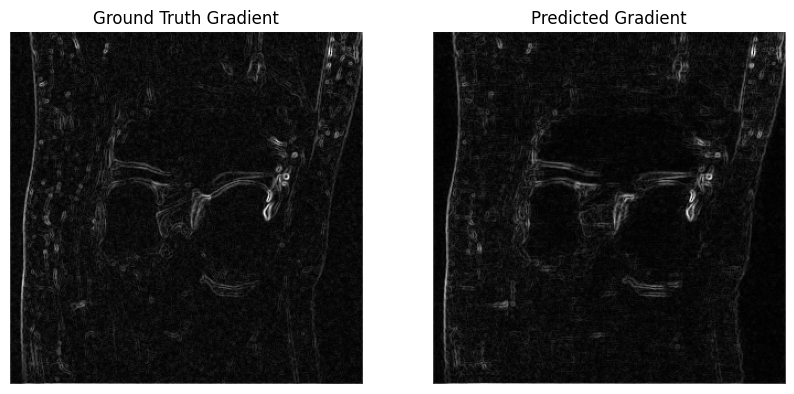

In [109]:
import torch
import matplotlib.pyplot as plt

# Initialize the inputs (ensure they're torch tensors)
und_imgs_np10 = und_imgs_np[20]
gt_imgs_np10 = gt_imgs_np[20]
recon_imgs_np10 = recon_imgs_np[20]

noisy = torch.tensor(und_imgs_np10, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
ground_truth = torch.tensor(gt_imgs_np10, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
predicted = torch.tensor(recon_imgs_np10, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Instantiate the DualStreamLoss
dual_stream_loss = DualStreamLoss(lambda_1=0.4, lambda_2=1.0, lambda_3=0.6)

# Calculate the total loss and gradients
total_loss, gt_grad, pd_grad = dual_stream_loss(ground_truth, predicted)

# Display the total loss value
print("Total Loss:", total_loss.item())

# Display the gradients of ground truth and predicted images
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(gt_grad[0, 0].cpu().detach().numpy(), cmap='gray')
axs[0].set_title("Ground Truth Gradient")
axs[0].axis("off")

axs[1].imshow(pd_grad[0, 0].cpu().detach().numpy(), cmap='gray')
axs[1].set_title("Predicted Gradient")
axs[1].axis("off")
plt.show()